---
title: EDA I
---

::: {note} Learning Outcomes
- Grasp the importance of asking good questions.
- Understand the process of acquiring data.
- Learn to manipulate tabular data for your purposes.
- Figure out how to express data manipulations in plain English
- Become familiar with some conversions between plain English and commands in both `polars` and `SQL`.
:::

## Exploratory Data Analysis

The the first step of working with a dataset is called Exploratory Data Analysis, or EDA for short. We are going to show what that means through some examples.

Most of the data we work with in this class is going to be **tabular data. That is data that lives in a table. Typically, it looks something like this:

In [58]:
import polars as pl
import seaborn as sns
import numpy as np

sns.set_palette("colorblind")

In [59]:
elections = pl.read_csv("data/elections.csv")
elections

Year,Candidate,Party,Popular vote,Result,%
i64,str,str,i64,str,f64
1824,"""Andrew Jackson""","""Democratic-Republican""",151271,"""loss""",57.210122
1824,"""John Quincy Adams""","""Democratic-Republican""",113142,"""win""",42.789878
1828,"""Andrew Jackson""","""Democratic""",642806,"""win""",56.203927
1828,"""John Quincy Adams""","""National Republican""",500897,"""loss""",43.796073
1832,"""Andrew Jackson""","""Democratic""",702735,"""win""",54.574789
…,…,…,…,…,…
2024,"""Donald Trump""","""Republican""",77303568,"""win""",49.808629
2024,"""Kamala Harris""","""Democratic""",75019230,"""loss""",48.336772
2024,"""Jill Stein""","""Green""",861155,"""loss""",0.554864


We have a bunch of rows and columns. Each row represents one observation. In this case, a single person running for president in a particular in the US in a particular year. Each column represents some characteristic/featue/information about that row, about that observation.

In the second row, we have John Quincy Adams, who ran in 1824. You can see the party he ran under, how many votes he won, the percent of the vote that he got, and whether or not he won. This is uh what tabular data looks like. 

The vast majority of the data we look in this class will either be tabular, or data that we can massage or push into being tabular.

### Languages and Libraries

In Data 8, you worked with tabular data using the `datascience` library and tables. In Data 100, **we are going to use a new-ish industry standard library** called `polars`. We are also going to use `SQL`, which hopefully you remember from CS 61A or Data 88C. 

`polars` is a Python library (that also works in R, Rust and many other languages) for working with tabular data in what are called **data frames**. It is very similar to the most widely adopted industry standard, `pandas`, which is what we used in earlier iterations of this class. In comparison, `polars` is more similar to the `datascience` library from Data 8. `polars` is also growing in popularity very quickly. 

**The primary goal of this class is not to learn the syntax**, but rather to learn the big ideas. If you need to use `pandas` when you get your first job, you will be able to learn it on the fly. `polars` is also much more efficient. It scales up better, which is great for many real world applications. 

Meanwhile, `SQL` is a declarative programming language that is completely different from Python, and used for working with tabular data that live in databases. We will talk more about this in later sections. Most of the SQL that we do in this class will be a review from CS 61A, but we will tie it into the `polars` code as we are learning.

## Developing Data Science Skills

In the coming sections, we will explore the mental frameworks around manipulating and visualizing tabular data. This is the same regardless of the language you're working in, whether that be `polars`, `pandas`, `R`, and even Excel. What we are teaching you is not necessarily the nitty-gritty details of `polars`. 

```{image} images/polars.png
:alt: Image of the polar bear icon for the polars data processing library in Python, along with text that says "polars".
:width: 500
```

We want you to come away from the next few weeks understanding the big ideas, as well as questions such as:
- What do I do when I get a dataset?
- How do I think about manipulating it? 

You have to know how to write code to do what we are going to do, and you have to know how to read and understand code. But fundamentally, Data 100 **is not a coding class**. 

We are trying to give you a shared language that you can use to communicate to people, "Here is what I did to my table." You might also be able to prompt a large language model using this clear language, so that it can write code or visualize something for you.

## EDA Workflow

What does a workflow like this look like? Oftentimes, there will be some database that has many many different tables.

- Perhaps you are working with a company that has a giant database somewhere in the cloud, with gigabytes, terabytes, or even petabytes of data.

- That database may be constantly updated, e.g. for every transaction a customer makes. You are going to use `SQL` to get a snapshot of that data at some point in time. You then work with that snapshot for the next few months.

- You use `polars`, `R`, Excel, or `pandas` to manipulate and play around with the data.

- You visualize it using one of the visualization libraries.

- Repeat previous steps as necessary, and as new questions come up.

**This is a typical data science workflow.** You get some data from a database, work with a snapshot, and see what information you can draw out of that data.

## Introducing Our Data and Task

We'll work with an example that you're all very familiar with: college admissions.

The most common path to UC Berkeley is by applying in 12th grade from a public high school. This path involves three steps, each of which involves a **decision**:
1. Students **apply** to UC Berkeley.
2. UC Berkeley decides whether to **admit** each student who applies.
3. Finally, each student decides whether they will **attend** UC Berkeley.

We'll focus on this path for our analysis, but it's important to remember it isn't the only one: students can apply from private schools, out-of-state schools, international schools, community colleges, other universities, and so on.

### The Task

Suppose you're an analyst working with the UC Berkeley admissions office. Your manager asks you to "find five schools that defy typical patterns of application, admission, or attendance." Based on your analysis, they'll visit the schools and understand what is and isn't working.

In answering this question, we'll learn a lot along the way about how to approach open-ended questions like this that are common in real-world data science workflows. We'll learn how to understand and contextualize data, how to make analysis plans and implement them in code, and how to visualize results.

### Questions Relevant to Our Task

We will now focus on asking good clarifying questions. Some examples that are relevant to your manager's question about five atypical schools:

- What is the motivation for this task in the first place?
    - Are there fewer people attending than we would usually expect?
    - Are we exploring changes in the student population?

- What data can we access?
    - Where do we have to look for relevant data?
    - Who has access to the data we need?

- Why five schools?
    - Why not fewer? 
    - Why not more?

- Why California public schools specifically?
    - Why not a different state?
    - Why not private schools?
    - Why not transfer students?
    - Why not community colleges?

- What does "typical" mean?
    - Typical in what way?
        - There are so many ways for something to be typical or not typical.
    - What does it mean to defy typical?

- Out of the three stages we defined, which one do we care about?
    - All of them equally?
    - Two of them more than one?

- Do we want to look at schools over time or just in one year?
    - Are we only interested in what is happening right now?
    - Are we interested in the past? 
    - Right now, there is an active debate over whether the SAT should be brought back for admissions for students in the UC system. Do we want to compare data from before the SAT requirement was removed with data from after the SAT was removed?

- Are we more interested in high-performing versus low-performing?

These are all important questions to ask. For every one of them, the answer will shape how we go about our analysis. For example, if we care a lot more about high-performing than low-performing, then we should spend more of our analysis time and effort on the schools that do well. For low-performing, vice versa.

Most importantly: What kind of data do we have access to? And what data could we request access to? You will see that the answer is often more than you might think.

## Finding Our Data

What is the data that we are going to be working with? This is data from the University of California's [official website](https://www.universityofcalifornia.edu/about-uc/information-center/admissions-source-school). 

We have all this information on freshman admission and transfer admission. Out of the options for freshman admission, we will be looking at "Counts of fall freshmmen by race/ethnicity", and then selecting "California public high schools" out of the available datasets.

```{image} images/uc_site.png
:alt: Screenshot of the University of California website, with a table displaying data regarding the UC Berkeley admissions process. Each row represents a public school in the state of California.
:width: 400
```

For each of these schools, we have the following information:
- the name of the school
- the city
- the county
- the counts for these three stages:
    - applied
    - admitted
    - enrolled

### Explaining Missing Data

There are some things we should notice. First off, some of these are blank. Why might some of these entries be blank? Here are some possible explanations:

- Blank entries could represent zero students who applied, were admitted, or chose to enroll.
- Blank entries could reflect data that the schools or UC could not access or verify.
- Blank entries could be instances when there were not enough people for the data to remain anonymous[^1].
    - If only one person from a given school applied to UC Berkeley, and you know that your friend applied there, then you could immediately find out whether or not your friend was admitted. This is a serious privacy concern.

In this case, the answer is noted directly below the dataset. Blank cells do reflect instances where fewer than five students in a given category ("all", or a specific race/ethncity) applied, or fewer than three were admitted/enrolled. A lot of the time, it will not be that easy. You may  have to go on a whole quest to understand the cause of missing data!

However, these are important concerns. We cannot do any analysis on the schools that have blank data, which means that we are probably going to have to exclude them from whatever we do. When we end up excluding missing information, it is important to keep in mind what we are losing. Data from an important subgroup could be missing at a higher rate, and thus affect any subsequent analysis!

[^1]: There's a really interesting paper from Latana Sweeney (that she wrote back in 2000) that highlighted this problem for the first time. It was a very embarrassing story about the health records of the governor of Massachusetts getting released. Would recommend checking it out if you have some extra time. It's been in the news!

:::{note} Be Scrappy With Data!
One major thing we want to impart to you is that there is a ton of information and data available out there. Much of the time, if you start a question and wish that you had access to certain data, it turns out that you actually do have access to it. It is out there as a public dataset, or it is out there as a dataset with some limitations. You just have to talk to the right person, fill the right thing out to get access to it, etc. 

Generally, you always want to have the mindset of, "Let me try to get access to that data," instead of, "Ah, can't do it, don't have the data." You are not helpless. Try to have that scrappy kind of resourceful uh mindset.
:::

## Opening Our Data

For our purposes, we are going to focus on public high school data for students admitted in 2025. I would use 2026, but the University of California has not released that information yet. 

Let us start by looking at the data.

In [60]:
hs = pl.read_csv('data/pivoted-ucb-data.csv')
hs

school,city,county,applied,admitted,attended
str,str,str,i64,i64,i64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3
…,…,…,…,…,…
"""YORBA LINDA HIGH SCHOOL""","""Yorba Linda""","""Orange""",86,8,3
"""YOSEMITE HIGH SCHOOL""","""Oakhurst""","""Madera""",7,null,null
"""YREKA HIGH SCHOOL""","""Yreka""","""Siskiyou""",8,null,null


**English:**  
  
Load in the dataset.

**Polars code:**
```python
hs = pl.read_csv('data/pivoted-ucb-data.csv')
hs
```

**SQL code:**
```sql
SELECT *
FROM admissions
```

- **CSV**: Comma separated values file.
    - Common way to store tabular data.
- **hs**: A `DataFrame`, the `polars` object for tabular data.

:::{note} CSV Structure
:open: false

What does CSV data look like? 

```{image} images/csv_view.png
:alt: Screenshot of our CSV (Comma Separated Values) data.
:width: 500
```

The first row contains the names of all of the column names, separated by commas. Each subsequent row contains the information for these columns, in the same order as the labels in the first row, and also separated by commas. Sometimes, there are two commas in a row when the value between those commas is missing. `polars` treats these blank, missing values as `null` values.

Our data could have instead come in other data types, such as TSV (Tab Separated Values) and JSON (JavaScript Object Notation).
:::

We have taken the applied, admitted, and enrolled data that were all piled together and pulled them out into a separate column for each step. This operation is called a pivot, and we will discuss this a little further at a later time. 

Looking at this preview, what do you know about this dataset, and what questions do you have?

Some observations:

- We know the data types of each column (str, i64, etc.)
- There are 1,268 schools in this dataset.
- There are multiple high schools with the same name (e.g. Abraham Lincoln High School)

Some possible questions:

- How do you work with data where some of the entries are empty or null?
    - We will take a shortcut answer for now, and discuss this in more depth in the future.
- Can we know graduating class size?
    - 200 students from Abraham Lincoln High School in San Francisco applied to UC Berkeley. Does this reflect a huge class size, or did almost all of the students from that school apply?

While we need code in order to load and manipulate the data, we want to emphasize the  thought process and the English descriptions of what we are doing. These days, the industry is shifting more and more towards the use of large language models (LLMs for short) to write code. This kind of plain-language-first approach is helpful both for prompting LLMs, and for organizing your own plan.

In this case, the plain language for what we are doing is that we are **loading in the dataset** and **showing a preview of the data**. 

How do we do that in `polars`, our data processing library? First, we use `pl`, to refer to `polars` (just like we would use `np` to refer to `NumPy`). From there, we have `pl.read_csv`, where CSV stands for "Comma Separated Values" (a common data format). We give this method the name of the file, and then we print the resulting `DataFrame`. Here it is again for your convenience:

```python
hs = pl.read_csv('data/pivoted-ucb-data.csv')
hs
```

:::{note} A Note On Using LLMs
While data scientists are doing more of their work usign LLMs now, you still need to be able to read and understand code that is shared with you by other data scientists. You also still need to check the output of LLMs to make sure that the output is correct and matches what you want.

There are plenty of reasons to be wary, skeptical, or opposed to using LLMs: 
- Energy consumption
- Water consumption
- Political and economic activities of the people who run the companies making these models

There are also studies that show that people who rely too much on LLMs lose their competency. There are seasoned engineers and data scientists who have said that they notice their abilities begin to atrophy if they spend too much time relying on an LLM. These are still widely-used tools in industry at the moment, so it is helpful to learn how to use them and prompt properly, but it is important to still keep your skills sharp.
:::

## Exploring Our Data

Returning to the topic of asking questions about our data, we will provide four in order to frame the coming exploration:

1. **Context and Inspection**
    - First, we always want to ask: Do you actually trust the data? How closely does it correspond to the truth?
        - Anytime we do data analysis, we're trying to understand some phenomenon in the real world, and data is always going to be an imperfect representation of the real world.
        - In this dataset, we saw that schools with very small numbers of applicants do not have data here, and thus are not reflected in this dataset. Context and inspection are extremely important.
    
2. **Extremes**
    - Which schools have the highest application, admission, or attendance rates?
        - We saw that Abraham Lincoln High School in San Francisco had 200 people applying. Is that big? How does that stack up as an application rate? 

3. **Distributions**
    - How much do application, admission, and attendance rates differ across schools?
        - Are they all fairly similar? Are they really spread out? How much variation is there?
        - Why is that variation there? What is the distribution? What are the different values that these rates take on across different schools?

4. **Correlation**
    - Are there other characteristics of the schools that are related and linked to these three (application, admission, and attendance rates)?
        - We'll get to correlation at a later point.

### Context and Inspection

We'll start with questions about **data provenence**. "Provenence" is a word that just mean data providence just means "where the data comes from". In this case, we got our data from the official UC website.

However, as you can observe, the data we loaded in looks different than the data directly on the website. We can observe that there is an Abraham Lincoln High School from Riverside in the data on the website, but our dataset does not have it. Our dataset only has LA, San Francisco, and San Jose. 

Why? The answer is that we have removed schools that have entirely missing values. Then, we show any missing values using null. Null is a standard computer science term that means "missing". **Null is not the same as zero.** Was it a good idea to drop rows entirely? Maybe, maybe not. Again, we will discuss ways to handle missing data a little later.

Do we trust this data? As mentioned, we drop schools that have fewer than five applicants. If we go to the California Department of Education website, we can see that there are 1,700 public schools in California that have 12th grade, but there are only 1,268 in our dataset. So, this data is not complete. *It is important to communicate this to anyone with whom you are sharing this data, or any resulting analysis!*

In [61]:
len(hs)

1268

**English:**  
  
Count the nubmer of rows in the dataset.

**Polars code:**
```python
len(hs)
```
OR
```python
hs.shape[0]
```

**SQL code:**
```sql
SELECT COUNT(*)
FROM admissions
```

Here, we used `len(hs)` to confirm the number of rows in our dataset. We could have also gone through `.hs.shape`, which produces the following tuple:

In [62]:
hs.shape

(1268, 6)

The first item in this tuple is the number of rows, and the second item is the number of columns. To access these, we would use brackets and the index of the item in the tuple. Thus, to get the number of rows, we would use `hs.shape[0]`, and to get the number of columns, we would use `hs.shape[1]`. Here is the latter:

In [63]:
hs.shape[1]

6

:::{note} Data Science Wisdom
Data is not necessarily truth. Data can be an approximation of reality, and sometimes a better approximation than other times. Seeing something in a table that looks official does not mean that it's reliable or a good representation of reality.

For example, not all public schools are represented, and we have limited information about schools with few applicants.

*Do not give up!* Data scientists often have to make do with imperfect data. Just make sure to be honest, transparent, and communicative about the data's limitations.
:::

### Extremes and Sorting

Here, we have a version of the dataset that is sorted by the number of people who who have applied. Because again, we want to know what are the extremes. Are there schools that are doing particularly well or particularly badly? Maybe we want to know what the largest number of applications per school.

In [64]:
hs.sort('applied', descending=False)

school,city,county,applied,admitted,attended
str,str,str,i64,i64,i64
"""ALTUS CHARTER SCHOOL OF SAN DI…","""San Diego""","""San Diego""",5,null,null
"""ANDERSON VALLEY JR SR HIGH SCH…","""Boonville""","""Mendocino""",5,null,null
"""BIG BEAR HIGH SCHOOL""","""Big Bear City""","""San Bernardino""",5,null,null
"""BOSTONIA GLOBAL""","""El Cajon""","""San Diego""",5,null,null
"""CALIFORNIA CITY HIGH SCHOOL""","""California City""","""Kern""",5,null,null
…,…,…,…,…,…
"""AMERICAN HIGH SCHOOL""","""Fremont""","""Alameda""",348,25,20
"""LOWELL HIGH SCHOOL""","""San Francisco""","""San Francisco""",363,42,29
"""ARCADIA HIGH SCHOOL""","""Arcadia""","""Los Angeles""",371,51,29


**English:**  
  
Sort the dataset in ascending order by the 'applied' column.

**Polars code:**
```python
hs.sort('applied', descending=False)
```

**SQL code:**
```sql
SELECT *
FROM admissions
ORDER BY applied ASC
```

Sorting is a common operation in EDA. Specifically, we want to sort the dataset in ascending order by the applied column.

We apply the `.sort` method to our `DataFrame`, where the `DataFrame` is the object type for our table. We pass the name of the column by which we are sorting, and then specify the sort order as ascending or descending using `descending=False` or `descending=True`, resepctively. In SQL. you would specify sort order as ascending or descending using `ORDER BY column_name ASC` or `ORDER BY column_name DSC`, respectively.

Keep in mind that `.sort` does not modify our original `DataFrame`. If we were to view the original `DataFrame` on its own again, by calling `hs`, we would see the data unsorted. If we want to modify our original `DataFrame` to reflect our new sort order, we would have to reassign `hs` to the result of this operation, using `hs = hs.sort('applied, descending=False)`.

We can see that Dougherty Valley High School in San Ramon had the highest number of applicants. But again, we don't know whether that's a reflection of a large class size, a large proportion of students applying, or both. 

What if we wanted to find the schools with the smallest number of applicants out of those that remain in our dataset?

In [65]:
hs['applied'].min()

5

**English:**  
  
Find the minimum of the 'applied' column.

**Polars code:**
```python
hs['applied'].min()
```

**SQL code:**
```sql
SELECT MIN(applied)
FROM admissions
```

We would apply brackets (containing the desired column name) to our `DataFrame`. This picks out the desired column as an array. It's not quite a NumPy array, though; it's slightly different. We'll talk a little bit more about that later.  

But we can pull out the min with `.min()`. In English, we would describe as, "Find the minimum of the applied column." Remember, we want to describe what we're doing in English and be able to write code that does it. And the code in DF applied.mmin SQL query looks like `SELECT MIN(applied)` from admissions.

Alongside the minimum, we can also find the maximum, mean, standard deviation, etc. 

Now, we might want to ask which schools have the highest application or admission or attendance rates.

We could sort in the opposite order, still sorting by the number of people who applied, but this time sorting in descending order (largest to smallest) instead of ascending order (smallest to largest).

In [66]:
hs.sort('applied', descending=True)

school,city,county,applied,admitted,attended
str,str,str,i64,i64,i64
"""DOUGHERTY VALLEY HIGH SCHOOL""","""San Ramon""","""Contra Costa""",542,44,32
"""DUBLIN HIGH SCHOOL""","""Dublin""","""Alameda""",435,40,27
"""ARCADIA HIGH SCHOOL""","""Arcadia""","""Los Angeles""",371,51,29
"""LOWELL HIGH SCHOOL""","""San Francisco""","""San Francisco""",363,42,29
"""AMERICAN HIGH SCHOOL""","""Fremont""","""Alameda""",348,25,20
…,…,…,…,…,…
"""VASQUEZ HIGH SCHOOL""","""Acton""","""Los Angeles""",5,null,null
"""VILLAGE ACADEMY HIGH SCHOOL""","""Pomona""","""Los Angeles""",5,null,null
"""WASHINGTON MIDDLE COLLEGE HS""","""West Sacramento""","""Yolo""",5,null,null


**English:**  
  
Sort the dataset in descending order by the 'applied' column.

**Polars code:**
```python
hs.sort('applied', descending=True)
```

**SQL code:**
```sql
SELECT *
FROM admissions
ORDER BY applied DSC
```

## Joining and Using External Data

However, these are still just the application **counts**; if we want to know the application **rates**, we need the denominator, which is the number of students who attended those schools.

You will often have data that is a count, while you actually want the rate. Or you may have the rate, while you actually want the count. **It's important to keep this distinction in mind, and not get them mixed up!**

In this instance, the rate is the number who applied, divided by the number of possible applicants. Do we have the number of possible applicants in this table? No! The number of possible applicants is really the number of 12th graders.

As noted earlier, we will be scrappy with data. We can go to the California Department of Education's website, where they have a great source of data.

```{image} images/ca_doe.png
:alt: A screenshot of the California Department of Education's Data & Statistics page, which has the following description: "Obtain access to educational data, statistics, and information about California's students and schools. There are three visible links. The first link is called "DataQuest", and has the following description: "DataQuest is the CDE's public data reporting website that provides meaningful data and statistics about California's K–12 public education system.". The second link is called "Data Reports", and has the following description: "Reports with data and statistics about California's K–12 public education system." The third link is called Downloadable Data Files", and has the following description: "Downloadable files with data and statistics about California's K–12 public education system."
:width: 500
```

While DataQuest and Data Reports are nice for some general purposes, data scientists need raw donwloadable data files that we can manipulate, join to other datasets, etc. Thus, we will

In order to use this new data containing the number of 12th graders in each school with our original dataset, we need to perform an operation called a **join**. which is hopefully familiar. We can join datasets containing different information to create a new dataset, particularly when there is some shared information (like the names of different schools). We will discuss joins in greater detail at a later time. But we have this data. We have the schools. 

We will join our existing data with census day data for California schools, which contains information on the total number of students enrolled per school in various grades. But in this case, the join is a little tricky, because **high school names might be written differently!** Maybe different styles of capitalization, different ways of writing different words, shortening, abbreviation, etc. We have done this for you behind the scenes, but it is an important part of the **data cleaning** process.

### Creating New Columns

For every high school, we still have our data from earlier: the city, the county, and the number of applied, admitted, and attending. With our joined data, we also have two new columns: the total number of students enrolled at each school, and the number of 12th graders enrolled at each school.

How do we use this to calculate the application rate? It is the number who applied, divided by the total number of 12th graders.

How do we do this in code? This is where the polar code starts to look a little different from what you might have seen before. First, we will read in the dataset resulting from our join operation.

In [67]:
hs_enroll = pl.read_csv('data/pivoted-ucb-data-w-enrollment.csv')

We add our new `'app_rate'` column using `pl.with_columns`. Inside the `.with_columns` method, we enter our new column's name (without quotes) and set it equal to the calculation that creates our new column's data. To perform this calculation, we divide the `'applied'` column by the `'grade_12'` column, which performs element-wise division between these two features for each row. In `polars`, we pull out these columns inside of expressions using `pl.col('column_name')`.

In [69]:
hs_enroll = hs_enroll.with_columns(
    app_rate=pl.col('applied') / pl.col('grade_12')
)
hs_enroll

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,app_rate
str,str,str,i64,i64,i64,i64,i64,f64
"""A B MILLER HIGH SCHOOL""","""Fontana""","""San Bernardino""",25,3,null,1961,485,0.051546
"""ABLE CHARTER""","""Stockton""","""San Joaquin""",8,null,null,1191,73,0.109589
"""ABRAHAM LINCOLN HIGH SCHOOL""","""Los Angeles""","""Los Angeles""",48,11,4,942,242,0.198347
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Francisco""","""San Francisco""",201,33,23,2037,489,0.411043
"""ABRAHAM LINCOLN HIGH SCHOOL""","""San Jose""","""Santa Clara""",56,8,3,1596,365,0.153425
…,…,…,…,…,…,…,…,…
"""YORBA LINDA HIGH SCHOOL""","""Yorba Linda""","""Orange""",86,8,3,1584,409,0.210269
"""YOSEMITE HIGH SCHOOL""","""Oakhurst""","""Madera""",7,null,null,557,133,0.052632
"""YREKA HIGH SCHOOL""","""Yreka""","""Siskiyou""",8,null,null,636,139,0.057554


**English:**  
  
Create a new column with the application rate for each school.

**Polars code:**
```python
hs_enroll = hs_enroll.with_columns(
    app_rate=pl.col('applied') / pl.col('grade_12')
)
hs_enroll
```

**SQL code:**
```sql
SELECT applied / grade_12 AS app_rate
FROM admissions
```

We now have our application rate. We want to ask, "Which schools have the highest application rates?" We will again **sort** the table by the relevant column, our `'app_rate'` column. We will sort in descending order, so that the largest values are at the top. That is our analysis plan in plain English: "Sort the data frame by the app rate column in descending order."

In [70]:
hs_enroll = hs_enroll.filter(pl.col('app_rate').is_not_null())

In [71]:
hs_enroll.sort('app_rate', descending=True)

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,app_rate
str,str,str,i64,i64,i64,i64,i64,f64
"""GIRLS ACADEMIC LEADERSHIP ACAD""","""Los Angeles""","""Los Angeles""",40,7,null,66,16,2.5
"""MCFARLAND HIGH SCHOOL""","""Mcfarland""","""Kern""",16,null,null,14,10,1.6
"""ALAMEDA SCIENCE & TECHNICAL IN…","""Alameda""","""Alameda""",42,7,6,167,29,1.448276
"""SCIENCE ACADEMY STEM MAGNET""","""North Hollywood""","""Los Angeles""",38,5,null,513,33,1.151515
"""MIDDLE COLLEGE HIGH SCHOOL""","""San Pablo""","""Contra Costa""",50,10,9,283,60,0.833333
…,…,…,…,…,…,…,…,…
"""SHAFTER HIGH SCHOOL""","""Shafter""","""Kern""",7,null,null,1655,431,0.016241
"""PERRIS HIGH SCHOOL""","""Perris""","""Riverside""",7,3,null,2106,497,0.014085
"""EXCELSIOR CHARTER SCHL VICTORV…","""Victorville""","""San Bernardino""",5,null,null,2120,371,0.013477


**English:**  
  
Sort the `DataFrame` by the 'app_rate' column in descending order.

**Polars code:**
```python
hs_enroll.sort('app_rate', descending=True)
```

**SQL code:**
```sql
SELECT applied / grade_12 AS app_rate
FROM admissions
ORDER BY app_rate DSC
```

## Inspecting Anomalies

This is our data, sorted in descending order by `'app_rate'`, but something is strange. One of the schools has an application rate of 2.5, and we can see that there are 16 12th graders even though there are 40 students who applied. 

How is it possible to have an application rate over 100%?

Maybe it's not just 12th graders who are applying. Maybe people graduated, took a gap year, and then applied, or maybe somebody applied from 11th grade. Again, it is important to consider whether our data are an incorrect reflection of reality. Are there assumptions we're making about our data that might not be quite right? 

But it is also important to consider whether you may have simply made a mistake, like pulling information for one of the joined datasets from the wrong year. Anytime you look at a dataset and you see something weird, you should always first check whether the abnormality is the result of a mistake on your end. 

It turns out, in this case, that this was the result of a mistake! You'll explore this mistake in your HW2 assignment.

### Filtering Rows

For now, we can see that there are few schools with these anomalous application rates, so we will simply filter them out. We know that there are no more schools with fitting this description in this dataset, because we sorted in descending order and can already see the largest application rates.

We will just remove those four schools for now and continue on with our analysis. Maybe there's something interesting going on with them, but we know that they're all small schools, so we'll leave them out for now.

So, we need to **filter** our dataset to remove those points. How do we filter? We want to filter out only rows where application rate is greater than one, or only keep rows where application rate is less than or equal to one. Then we want to sort.

In [72]:
hs_enroll = hs_enroll.filter(pl.col('app_rate') <= 1)
hs_enroll.sort('app_rate', descending=True)

school,city,county,applied,admitted,attended,tot_enrolled,grade_12,app_rate
str,str,str,i64,i64,i64,i64,i64,f64
"""MIDDLE COLLEGE HIGH SCHOOL""","""San Pablo""","""Contra Costa""",50,10,9,283,60,0.833333
"""MONTA VISTA HIGH SCHOOL""","""Cupertino""","""Santa Clara""",321,33,25,1636,421,0.76247
"""GRETCHEN WHITNEY HIGH SCHOOL""","""Cerritos""","""Los Angeles""",119,23,13,1018,163,0.730061
"""CALIFORNIA ACAD MATH & SCIENCE""","""Carson""","""Los Angeles""",115,24,11,667,163,0.705521
"""LYNBROOK HIGH SCHOOL""","""San Jose""","""Santa Clara""",314,34,25,1720,448,0.700893
…,…,…,…,…,…,…,…,…
"""SHAFTER HIGH SCHOOL""","""Shafter""","""Kern""",7,null,null,1655,431,0.016241
"""PERRIS HIGH SCHOOL""","""Perris""","""Riverside""",7,3,null,2106,497,0.014085
"""EXCELSIOR CHARTER SCHL VICTORV…","""Victorville""","""San Bernardino""",5,null,null,2120,371,0.013477


**English:**  
  
Filter data to rows where app_rate <= 1. Then, sort by app_rate.

**Polars code:**
```python
hs_enroll = hs_enroll.filter(pl.col('app_rate') <= 1)

hs_enroll.sort('app_rate', descending=True)
```

**SQL code:**
```sql
SELECT applied/grade_12 AS app_rate
FROM admissions
WHERE app_rate <= 1
ORDER BY app_rate DSC
```

In order to filter our rows, we use `.filter` in `polars`. We pull out the application rate column using `pl.col`, and say that it is less than or equal to one. Then we use `.sort` as before.  

In SQL, filtering happens with using the `WHERE` keyword. We redo all of the operations to create the `app_rate` column, because SQL would require us to create a new table in order to add a column.

:::{note} Filtering and Masks
It is also worth explaining how `.filter`, which we used earlier, actually works. You pass in something we call a mask, which is basically a list of rows that satisfy some sort of condition. Earlier, we used it to only keep rows with values less than or equal to 1. By stating `pl.col('app_rate') <= 1`, we create a mask that tells `.filter` to only keep rows for which this inequality is true.

You may have also noticed a hidden code cell just before we sorted `hs_enroll` for the first time. In that cell, we use `pl.col('app_rate').is_not_null()` as our mask, which leaves only those values of `'app_rate'` that are not `null`. If we hadn't run this first, our data would be clouded with many rows containing `null` values.
:::

## Defining Success

Now that we've filtered and sorted, do we have our answer to the original task that our manager assigned us? Have we found five schools that defy typical patterns of attendance? We have the five schools with the highest application rates, after all. 

However, we don't know whether or not this is typical, because we haven't defined what we mean by "typical".  

We have found the five schools with the highest application rates, but there is much that we have not checked out. We haven't looked at admission or attendance at all! Even within applcation rates, we haven't looked at low application rates, or at the center and variation of the distribution. We haven't looked at what is "typical" as a baseline against which to compare schools that "defy typical". 

If we look at these schools, we can see that one of these schools is pretty small, with a total of only 60 12th graders. Another school looks like a a special specialized school math and science academy.

Are these five a good representation of public schools in California? Maybe, maybe not. In order to answer the question of what is a good representation, we need to look at our dataset and understand the overall distribution.

:::{note} Data Science Wisdom
One of the key tasks that you need to do as a data scientist is to **define what success means**. You'll often need to transform vague instructions, like "Give me five schools that defy typical patterns of attendance," into concrete metrics. This will also mean communicating to your boss and/or other stakeholders about how you defined your metric, and discuss whether that metric makes sense for the current project. Data science requires a lot of collaboration and negotiation!
:::

## Some Code Specifics

First, we will go over some code that hid earlier in this course note. We start by importing `polars` as `pl` and `seaborn` as `sns`.

```python
import polars as pl
import seaborn as sns
import numpy as np

sns.set_palette("colorblind")
```


`seaborn` is the visualization library that we're going to use to create our visualizations. We also import `NumPy` as `np`, and set a color palette for `seaborn`.

Let's return to when we pulled out the `'applied'` column in our `hs` dataset using `hs['applied']`. This may feel familiar to using bracket notation to pull an item out of a `dict` by the name of its key.

In [73]:
hs['applied']

applied
i64
25
8
48
201
56
…
86
7
8


What is this single column object? It is something called a `Series`. This is kind of like an array, but instead of using `NumPy`, it uses something called Apache Arrow.  Don't try to use numpy functions on this object, it will break! You can still perform many of the same operations you would with a `NumPy` array by saying `.min()`, `.max()`, `.mean()`, and so on.

You can also use `.describe` on one of these Series objects to see many of these summary statistics at a glance. (There is no concise equivalent to this in `SQL`.)

In [74]:
hs['applied'].describe()

statistic,value
str,f64
"""count""",1268.0
"""null_count""",0.0
"""mean""",48.652997
"""std""",59.39565
"""min""",5.0
"""25%""",15.0
"""50%""",29.0
"""75%""",53.0
"""max""",542.0


You can also apply `.describe()` to a `DataFrame`, which simply presents these same summary statistics for every columnn in the `DataFrame`. This is unhelpful for string-valued columns, where summary statistics like `min`, `mean`, and `max` have no meaning.


If you want a `NumPy` array instead (which you may want for various reasons), then you would call `.to_numpy()`, as such:

In [76]:
hs['applied'].to_numpy()

array([25,  8, 48, ...,  8, 29, 20], shape=(1268,))

This then allows you to use `NumPy` functions directly:

In [77]:
np.min(hs['applied'].to_numpy())

np.int64(5)

Pulling a column out of a `DataFrame` into a 1-dimensional `Series` object is not the only way to pull out columns that you want. `pl.col('column_name')`, which we used earlier when we were creating our `'app_rate'` column, is how we call on individual columns inside of other `polars` expressions.

This is also how you **select** columns out of your `DataFrame`, as such:

```python
hs_enroll_subset = hs_enroll.select(pl.col('school'), pl.col('attended'))
hs_enroll_subset
```

When using `.select`, you can also plug in the names of the columns directly, like this:
```python
hs.select('school', 'attended')
```

However, it is generally more reliable to use `pl.col('column_name')`.

Again, we don't necessarily want you to know all of the details of these functions and methods, but rather to have a vague idea of how they work. If somebody gives you code and where they did some filtering, you should be able to make sure that they filtered correctly. You can read it and understand what's going on.

## Distributions

In order to talk about "typical", we have to understand how the data varies from school to school. We used `.describe` to calculate various summary statistics for the `'app_rate'` column, including a mean of 0.16 That is, across all 1,200 schools in my dataset, the average application rate was 16%. Additionally, the standard deviation was 13%, and we also had the 25th percentile, 50th percentile, and so on. The max is 83%.

Is this helpful? It does tell us something about our distribution, but a picture is worth a thousand words. Generally, we want to start with visualizations, and only see specific numbers afterwards. This can be counterintuitive, but humans generally much better at processing images than text.

### Boxplots

In particular, we're going to look at a boxplot. A boxplot is a visualization where has a  box with some whiskers on the ends, and potentially some dots outside of the whiskers.

<Axes: xlabel='app_rate'>

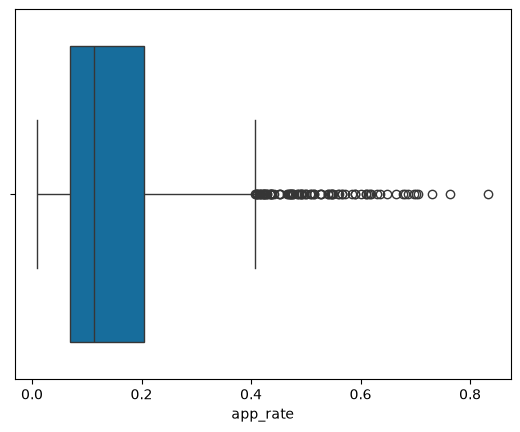

In [78]:
sns.boxplot(hs_enroll, x='app_rate')

**English:**  
  
Make a boxplot of the values in app_rate.

**Seaborn code:**
```python
sns.boxplot(hs_enroll, x='app_rate')

The box is bounded by the 25th percentile (or first quartile, or Q1) on the left side, and the 75th percentile (or third quartile, or Q3) on the right side. The line inside of the box is the median (or 50th percentile, or second quartile, or Q2).

The whiskers we get by computing something called the interquartile range, or IQR = Q3 - Q1. The left whisker ends at Q1 - (1.5 * IQR), and the right whisker ends at Q3 + (1.5 * IQR). Every point beyond those whiskers, or everything outside the range [Q1 - 1.5 IQR, Q3 + 1.5 IQR], we consider to be outliers.

This gives you a measure of how spread out your data set is. If you have data that are really spread out, your IQR is going to be really big, and it'll be really small for data with little overall spread.

:::{note} Arbitrary Heuristics
Why are outliers defined by being beyond 1.5 IQR from the box? This is pretty much an arbitrary decision, but many researchers find it to work fairly well.

You will find other such "arbitrary, but useful" values. It can be helpful to use these, but there are other times when you will want to think critically about such things and whether or not they make sense for a given situation!
:::


Again, helpful to think about how these visualizations work and how they would display datasets with different distributions.

Getting back to our distribution of application rates, the boxplot shows that most of the application rates fall approximately between 0% and 40%, with outliers beyond 40%.

### Histograms

We can also look at this data as a histogram, which comes with certain advantages and certain disadvantages.

<Axes: xlabel='app_rate', ylabel='Count'>

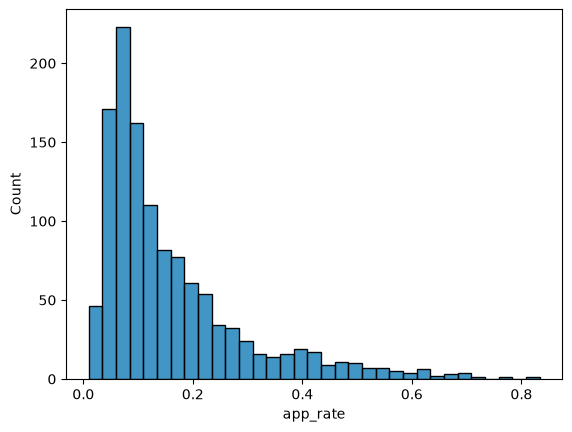

In [79]:
sns.histplot(hs_enroll, x='app_rate')

**English:**  
  
Make a histogram of the values in app_rate.

**Seaborn code:**
```python
sns.histplot(hs_enroll, x='app_rate')
```

We say that there is a long right tail, with values above 0.4 and there's a peak around 0.05 (or 5%). In a histogram, we say that there is **skew** in the direction in which the tail extends. Right skew indicates that the mean is greater than the median, as the mean is more greatly affected than the median by outlying data.

Here is another example of a histogram with right/positive skew, with mean > median:

```{image} images/right_skew.png
:alt: Histogram with a long right tail. The x-axis is labeled "Gross national income per capita, Atlas method: $: 2016".
:width: 500
```

And here is an example of a histogram with left/negative skew with mean < median:

```{image} images/left_skew.png
:alt: Histogram with a long left tail. Acess to an improved water source: % of population: 2015".
:width: 500
```

Which one of these is more common in the real world? Right skewed data happens to be much more common than left skewed data. Why might that be? Well, a lot of datasets we work with start at zero and extend positively, such as income.

The **mode** is the most frequent value of the distribution. If we have a distribution that has one clear peak, it's called unimodal (as in, a single mode). This includes all three histograms we've seen so far, including our histogram of application rates. 

A distribution with two peaks is called bimodal, and a distribution with more than two is called multimodal. These labels can be a little fuzzy, because it can be hard to tell whether or not something counts as an additonal peak, which depends on the calculation you use to distinguish peaks and what sort of threshold you use for that distinction. It is up to you to decide how important it is whether the data is unimodal, bimodal, etc.

Notably, it is impossible to recover this information using a boxplot! This is one major advantage of histograms over boxplots. You can get a more detailed idea of the shape of your data's distribution. However, depending on the bin sizes (how fine-grained your histogram is), this can surface what seem like important patterns or peaks, but are really distractions from the overarching pattern.

## Takeaway and Future Direction

We have explored how to find data, how to access and begin using our data, and how to ask important questions about our data. This has led us to inspect missing and anomalous data, check for extremes, examine distributions, and keep context in mind at all steps.

Why is there so much variation in application rate across schools? Well there are many different reasons. We'll start next time thinking about why those decisions might be complex, but we can bring in a lot of that data from external sources. We will start our next section by thinking about what other information we can bring in about these schools, in order to help us understand why there might be variation here.